In [87]:
import numpy as np
import numpy.linalg as linal
import pandas as pd
import sympy
import matplotlib.pyplot as plt

# Part 1 : Establishing the linear relationship between the parameters

In [88]:
df = pd.read_excel(r'Assignment2/Assignment2/ghg-concentrations_1984-2014.xlsx')
mean = [ df['CO2 (ppm)'].mean(), df['CH4 (ppb)'].mean(), df['N2O (ppb)O3 ('].mean(), df['O3 (Dobson unit)'].mean(), df['Temp (deg F)'].mean() ]
CO2 = df['CO2 (ppm)'] - df['CO2 (ppm)'].mean()
CH4 = df['CH4 (ppb)'] - df['CH4 (ppb)'].mean()
N2O = df['N2O (ppb)O3 ('] - df['N2O (ppb)O3 ('].mean()
O3 = df['O3 (Dobson unit)'] - df['O3 (Dobson unit)'].mean()
Temp = df['Temp (deg F)'] - df['Temp (deg F)'].mean()
y = np.transpose(np.matrix(Temp))
df

,Year,CO2 (ppm),CH4 (ppb),N2O (ppb)O3 (,O3 (Dobson unit),Temp (deg F)
0,1984,344.58,1655.843333,304.149167,282.075250,0.270
1,1985,346.04,1668.064167,304.270833,278.234482,0.234
2,1986,347.39,1681.835000,304.555833,279.845398,0.414
3,1987,349.16,1693.105000,305.145455,279.769180,0.666
4,1988,351.56,1703.948333,306.035833,279.117045,0.666
5,1989,353.07,1717.980833,307.043333,283.993979,0.522
6,1990,354.35,1731.451667,308.169167,280.411319,0.774
7,1991,355.57,1740.968333,308.908333,282.554298,0.720
8,1992,356.38,1745.487500,309.737500,275.761171,0.450
9,1993,357.07,1748.661667,309.907917,271.723276,0.504


In [89]:
data_shifted = np.transpose(np.matrix([ CO2, CH4, N2O, O3]))

In [90]:
N = 31 # Sample size
p = 4  # number of variables 

data_shiftedT = np.transpose(data_shifted)
Covariance_matrix = data_shiftedT*data_shifted/N
beta = linal.inv(N*Covariance_matrix)*data_shiftedT*y
for i in range(4) :
    print(f'beta_{i+1} : {beta[i,0]}',end=' ,')
    

beta_1 : 0.06071437169214489 ,beta_2 : 0.00591386738116531 ,beta_3 : -0.14652443172116086 ,beta_4 : 0.008036502363037318 ,

In [91]:
beta_0 = mean[4] - np.matrix([mean[0], mean[1], mean[2], mean[3]])*beta
print(f'beta_{0} : {beta_0[0,0]}')

beta_0 : 11.799825684249502


In [92]:
sTemp = sympy.symbols('Temp')
sCO2 = sympy.symbols('CO2')
sCH4 = sympy.symbols('CH4')
sN2O = sympy.symbols('N2O')
sO3 = sympy.symbols('O3')

In [93]:
sTemp = beta[0,0]*sCO2 + beta[1,0]*sCH4 + beta[2,0]*sN2O + beta[3,0]*sO3 + beta_0[0,0]

In [94]:
corr = np.transpose(y)*data_shifted/31
print(corr)

[[ 4.19215523 12.23450185  1.72675437 -0.0411108 ]]


In [95]:
print('Correlation Coefficient between Temperature and CO2 :', corr[0,0]/np.sqrt(Covariance_matrix[0,0]*y.var()))
print('Correlation Coefficient between Temperature and CH4 :', corr[0,1]/np.sqrt(Covariance_matrix[1,1]*y.var()))
print('Correlation Coefficient between Temperature and N2O :', corr[0,2]/np.sqrt(Covariance_matrix[2,2]*y.var()))
print('Correlation Coefficient between Temperature and O3  :', corr[0,3]/np.sqrt(Covariance_matrix[3,3]*y.var()))

Correlation Coefficient between Temperature and CO2 : 0.8862841443735727
Correlation Coefficient between Temperature and CH4 : 0.8821878370782464
Correlation Coefficient between Temperature and N2O : 0.8837455661672756
Correlation Coefficient between Temperature and O3  : -0.05914235211377435


### Positive Correlation occurs between Temperature and CO2, CH4, N2O
### Negative Correlation occurs between Temperature and O3

# Part 2 : Estimating variance in temperature and confidence intervals for the regression coefficients

Error variance

$\hat{\sigma}^2$= $\frac{\left(y_{i} - \hat{y_{i}}\right)^2}{n-p-1}$ \
N = 31 \
p = 4

In [96]:
def calculate_estimate(i) :
    return sTemp.subs({sCO2: df['CO2 (ppm)'][i], sCH4 : df['CH4 (ppb)'][i], sN2O : df['N2O (ppb)O3 ('][i], sO3 : df['O3 (Dobson unit)'][i]})

In [97]:
calculate = np.vectorize(calculate_estimate)
var1 = [x for x in range(31)]
estimates = np.matrix(calculate(var1))

In [98]:
error = np.matrix(df['Temp (deg F)']) - estimates
EV    = error*np.transpose(error)/(N-p-1)
print(f"Error variances : {EV[0,0]}")

Error variances : 0.0166313122781198


### Finding confidence intervals of the parametes $\beta_{1,...,p}$
Here the Covariance matrix is 
$\frac{X^{T}X}{N}$

N - p - 1 = 26

Hence the corresponding t score from T distribution for 26 degrees of freedom and 95% confidence interval is 2.056

In [99]:
T_score = 2.056
C = linal.inv(N*Covariance_matrix)
def std_error(j) :
    return (EV[0,0]*C[j,j])**0.5

In [100]:
lower = []
upper = []
for j in range(4) :
    lower.append(beta[j,0] - T_score*std_error(j))
    upper.append(beta[j,0] + T_score*std_error(j))

In [101]:
print(f'Confidence Intervals : ')
print(f'beta_1 = {lower[0]} to {upper[0]}')
print(f'beta_2 = {lower[1]} to {upper[1]}')
print(f'beta_3 = {lower[2]} to {upper[2]}')
print(f'beta_4 = {lower[3]} to {upper[3]}')

Confidence Intervals : 
beta_1 = 0.00495293486831026 to 0.116475808515980
beta_2 = 0.00179588602841499 to 0.0100318487339156
beta_3 = -0.299315036199628 to 0.00626617275730645
beta_4 = -0.0136887471967863 to 0.0297617519228610


## Calculating Confidence interval for $\beta_{0}$
$T_{score}$ = 2.045 ,for N-2 = 29 

In [102]:
EV0 = 0
for j in range(31) :
    EV0 += EV*data_shifted[j]*C*np.transpose(data_shifted[j])/N

In [103]:
lower.append(beta_0[0,0] - 2.056*(EV0[0,0]**0.5))
upper.append(beta_0[0,0] + 2.056*(EV0[0,0]**0.5))
print(f'beta_0 = {lower[4]} to {upper[4]}')

beta_0 = 11.7045821465918 to 11.8950692219072


---

## Detection Outliers using residual plots :

$$Error = y_{i} - \hat{y_{i}}$$

In [104]:
N = len(df)

------------------- 0 ---------------------
R2 value            :  0.8405555843859701


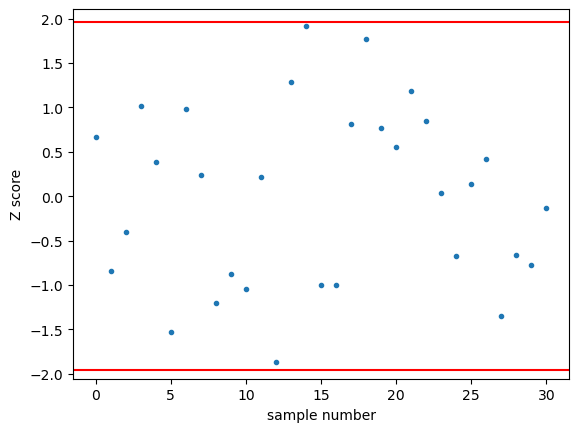

All the outliers have been removed successfully
Number of outliers removed     : 0
[[0.01663131]]


In [105]:
dft = df.copy()
iter = 0

X   = np.matrix(dft.iloc[:,[1,2,3,4]])                    # 31 x 4
y   = np.transpose(np.matrix(dft.iloc[:,5]))              # 31 x 1

while True :
    print('-------------------',iter,'---------------------')

    Xms = X - X.mean(axis=0)
    yms = y - y.mean()

    beta = linal.inv(np.transpose(Xms)*Xms)*np.transpose(Xms)*yms
    beta0= y.mean() - np.matrix(X.mean(axis=0))*beta

    error = y - X*beta - beta0
    estimate_variance =  np.transpose(error)*error/(N-p-1)

    R2_RM = 1 - estimate_variance*(N-p-1)/(y.var()*N)
    print("R2 value            : ", R2_RM[0,0])

    N = len(X)
    zi = np.zeros(N)

    
    for i in range(N) :
        pii = (1/N) + (Xms[i]*linal.inv(np.transpose(Xms)*Xms)*np.transpose(Xms[i]))
        var = estimate_variance*( 1 - pii )
        zi[i] = error[i,0]/(var[0,0]**0.5)

    i = [ m for m in range(N) ]
    plt.plot(i,zi,'.')
    plt.axhline(1.959,color = 'red')
    plt.axhline(-1.959, color = 'red')
    plt.xlabel("sample number")
    plt.ylabel("Z score")
    plt.show()

    max_zi = zi.argmax()
    min_zi = zi.argmin()


    if zi[max_zi] < 1.959 and zi[min_zi] > -1.959 :
        print("All the outliers have been removed successfully")
        print(f"Number of outliers removed     : {31 - N}")
        break 
    else :
        if zi[max_zi] > -zi[min_zi] :
            X = np.delete(X, obj = max_zi, axis=0)
            y = np.delete(y, obj = max_zi, axis=0)
        elif zi[max_zi] < -zi[min_zi] :
            X = np.delete(X, obj = min_zi, axis=0)
            y = np.delete(y, obj = min_zi, axis=0)

    iter = iter + 1

print(estimate_variance)

* As we can see that all the values lie within 95 % confidence interval none of the samples are outliers 
* Hence no samples were removed from the feature matrix

## Finding the new Confidence Intervals 

In [106]:
print(beta, beta0)
np.transpose(yms)*Xms/31
estimate_variance - EV[0,0]

[[ 0.06071437]
 [ 0.00591387]
 [-0.14652443]
 [ 0.0080365 ]] [[11.79982568]]


matrix([[2.08166817117217e-17]], dtype=object)

In [107]:
T_score = 2.056
C       = estimate_variance[0,0] * linal.inv(np.transpose(Xms)*Xms)

l = []
u = []
for j in range(4) :
    l.append(beta[j,0] - T_score*(C[j,j]**0.5))
    u.append(beta[j,0] + T_score*(C[j,j]**0.5))

print(f'95% Confidence Intervals : ')
print(f'beta_1 = {l[0]} to {u[0]}')
print(f'beta_2 = {l[1]} to {u[1]}')
print(f'beta_3 = {l[2]} to {u[2]}')
print(f'beta_4 = {l[3]} to {u[3]}')

sum = 0
for i in range(N) : 
    sum += estimate_variance[0,0]*X[i]*linal.inv(np.transpose(Xms)*Xms)*np.transpose(X[i])/N 

l.append(beta0[0,0] - T_score*(sum[0,0])**0.5)
u.append(beta0[0,0] + T_score*(sum[0,0])**0.5)
    
print(f'beta_0 = {l[4]} to {u[4]}')

95% Confidence Intervals : 
beta_1 = 0.004952934868309895 to 0.11647580851597769
beta_2 = 0.0017958860284149466 to 0.010031848733915567
beta_3 = -0.29931503619962174 to 0.006266172757309257
beta_4 = -0.013688747196786252 to 0.029761751922861065
beta_0 = -12.994894452694503 to 36.59454582119156


* From the above confidence intervals we can see that the coefficients of O3 and N2O has 0 in its confidence interval
* But the confidence interval of Ozone is smaller so we first remove O3 from the regression equation by null hypothesis 
* Now After removing the variables we recompute the parameters and their corresponding Confidence Intervals 
* This process is repeated till we don't find 0 in any of the confidence intervals

In [108]:
# Performing Regression again after removing ozone from the data matrix
p = 3
dft = df.copy()
iter = 0

X   = np.matrix(dft.iloc[:,[1,2,3]])                    # 31 x 4
y   = np.transpose(np.matrix(dft.iloc[:,5]))              # 31 x 1

while True :

    Xms = X - X.mean(axis=0)
    yms = y - y.mean()

    beta = linal.inv(np.transpose(Xms)*Xms)*np.transpose(Xms)*yms
    beta0= y.mean() - np.matrix(X.mean(axis=0))*beta

    error = y - X*beta - beta0
    estimate_variance =  np.transpose(error)*error/(N-p-1)

    R2_RM = 1 - estimate_variance*(N-p-1)/(y.var()*N)
    print("R2 value                 : ", R2_RM[0,0])

    N = len(X)

    T_score = 2.056
    C       = estimate_variance[0,0] * linal.inv(np.transpose(Xms)*Xms)

    l = []
    u = []
    for j in range(3) :
        l.append(beta[j,0] - T_score*(C[j,j]**0.5))
        u.append(beta[j,0] + T_score*(C[j,j]**0.5))

    print(f'95% Confidence Intervals : ')
    print(f'beta_1 = {l[0]} to {u[0]}')
    print(f'beta_2 = {l[1]} to {u[1]}')
    print(f'beta_3 = {l[2]} to {u[2]}')

    sum = 0
    for i in range(N) : 
        sum += estimate_variance[0,0]*X[i]*linal.inv(np.transpose(Xms)*Xms)*np.transpose(X[i])/N 

    l.append(beta0[0,0] - T_score*(sum[0,0])**0.5)
    u.append(beta0[0,0] + T_score*(sum[0,0])**0.5)
    
    print(f'beta_0 = {l[3]} to {u[3]}')

    break

R2 value                 :  0.837008375273747
95% Confidence Intervals : 
beta_1 = 0.01112890672078306 to 0.11918242067689933
beta_2 = 0.0017105637436432876 to 0.00985064835772166
beta_3 = -0.305833197906768 to -0.007634216203871141
beta_0 = -6.239455152929917 to 37.924331641407704


## OBSERVATIONS :
* We can see that after remvoing O3 from the equation we don't get 0 in any of the Confidence Intervals
* Also our R $^2$ value has fallen from **0.84055554** to **0.83700837**

In [109]:
print(beta, beta0)

[[ 0.06515566]
 [ 0.00578061]
 [-0.15673371]] [[15.84243824]]


## FINAL OLS REGRESSION MODEL : 

$$ Temperature = 15.84234 + 0.06515566\cdot CO_2 + 0.00578061\cdot CH_4 - 0.15673371\cdot N_2O $$

In [119]:
beta = beta/beta[0,0]
print("Computed GWP values : ")
print(f"CO2                 : {beta[0,0]}                       [refrence level]")
print(f"CH4                 : {beta[1,0]}")
print(f"N2O                 : {beta[2,0]}")

Computed GWP values : 
CO2                 : 1.0                       [refrence level]
CH4                 : 0.08871993196786794
N2O                 : -2.4055269819637664
